In [1]:
# Cell 0
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ModuleNotFoundError:
    pass


Mounted at /content/drive


In [2]:
# Cell 1
!pip install hmmlearn pmdarima --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 28.2 MB/s eta 0:00:00


In [3]:
# Cell 2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import os
import warnings

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

try:
    from hmmlearn import hmm
    HMM_AVAILABLE = True
except (ImportError, ModuleNotFoundError):
    HMM_AVAILABLE = False

from pmdarima import auto_arima

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

COUNTRIES = ['Bangladesh', 'India', 'Pakistan']

BASE_DIR        = os.getcwd()
LOCAL_DATA_PATH = os.path.join(BASE_DIR, 'owid-covid-data.csv')
LOCAL_OUT_DIR   = os.path.join(BASE_DIR, 'outputs')

if os.path.exists(LOCAL_DATA_PATH):
    DATA_PATH = LOCAL_DATA_PATH
    OUT_DIR   = LOCAL_OUT_DIR
else:
    DATA_PATH = '/content/drive/MyDrive/CSE427/Time Series Forecasting/owid-covid-data.csv'
    OUT_DIR   = '/content/drive/MyDrive/CSE427/Time Series Forecasting'

TRAIN_RATIO      = 0.80
FORECAST_HORIZON = 180
HMM_N_ITER       = 200
HMM_COV_TYPE     = 'diag'
HMM_MIN_COVAR    = 1e-3

print(f"HMM_AVAILABLE : {HMM_AVAILABLE}")
print(f"DATA_PATH     : {DATA_PATH}")
print(f"OUT_DIR       : {OUT_DIR}")


HMM_AVAILABLE : True
DATA_PATH     : /content/drive/MyDrive/CSE427/Time Series Forecasting/owid-covid-data.csv
OUT_DIR       : /content/drive/MyDrive/CSE427/Time Series Forecasting


In [4]:
# Cell 3
os.makedirs(OUT_DIR, exist_ok=True)

df_raw = pd.read_csv(
    DATA_PATH,
    usecols=['location', 'date', 'total_vaccinations'],
    parse_dates=['date']
)
df_raw = df_raw[df_raw['location'].isin(COUNTRIES)].copy()
df_raw.sort_values(['location', 'date'], inplace=True)
df_raw.reset_index(drop=True, inplace=True)

print(df_raw.shape)
print(df_raw.dtypes)
df_raw.head(10)


(4161, 3)
location                      object
date                  datetime64[ns]
total_vaccinations           float64
dtype: object


,location,date,total_vaccinations
0,Bangladesh,2020-01-03,NaN
1,Bangladesh,2020-01-04,NaN
2,Bangladesh,2020-01-05,NaN
3,Bangladesh,2020-01-06,NaN
4,Bangladesh,2020-01-07,NaN
5,Bangladesh,2020-01-08,NaN
6,Bangladesh,2020-01-09,NaN
7,Bangladesh,2020-01-10,NaN
8,Bangladesh,2020-01-11,NaN
9,Bangladesh,2020-01-12,NaN


In [5]:
# Cell 4
for country in COUNTRIES:
    sub = df_raw[df_raw['location'] == country]
    print(
        f"{country}: {len(sub)} rows | "
        f"{sub['date'].min().date()} to {sub['date'].max().date()}"
    )


Bangladesh: 1386 rows | 2020-01-03 to 2023-10-19
India: 1390 rows | 2020-01-03 to 2023-10-23
Pakistan: 1385 rows | 2020-01-03 to 2023-10-18


In [6]:
# Cell 5
null_counts    = df_raw.groupby('location')['total_vaccinations'].apply(lambda x: x.isnull().sum())
present_counts = df_raw.groupby('location')['total_vaccinations'].count()
missing_pct    = (null_counts / (null_counts + present_counts) * 100).round(2)

null_audit = pd.DataFrame({
    'missing'     : null_counts,
    'present'     : present_counts,
    'missing_pct' : missing_pct
})
print(null_audit.to_string())


            missing  present  missing_pct
location                                 
Bangladesh      903      483        65.15
India           405      985        29.14
Pakistan       1007      378        72.71


In [7]:
# Cell 6
country_data = {}

for country in COUNTRIES:
    subset = df_raw[df_raw['location'] == country][['date', 'total_vaccinations']].copy()
    subset = subset.dropna(subset=['total_vaccinations'])
    subset = subset.drop_duplicates(subset=['date'])
    subset = subset.set_index('date').sort_index()
    subset = subset.asfreq('D')
    subset['total_vaccinations'] = subset['total_vaccinations'].interpolate(method='linear')
    country_data[country] = subset

for country, df in country_data.items():
    n_null = df['total_vaccinations'].isnull().sum()
    print(f"{country}: {len(df)} observations after preprocessing | {n_null} remaining nulls")


Bangladesh: 996 observations after preprocessing | 0 remaining nulls
India: 1012 observations after preprocessing | 0 remaining nulls
Pakistan: 967 observations after preprocessing | 0 remaining nulls


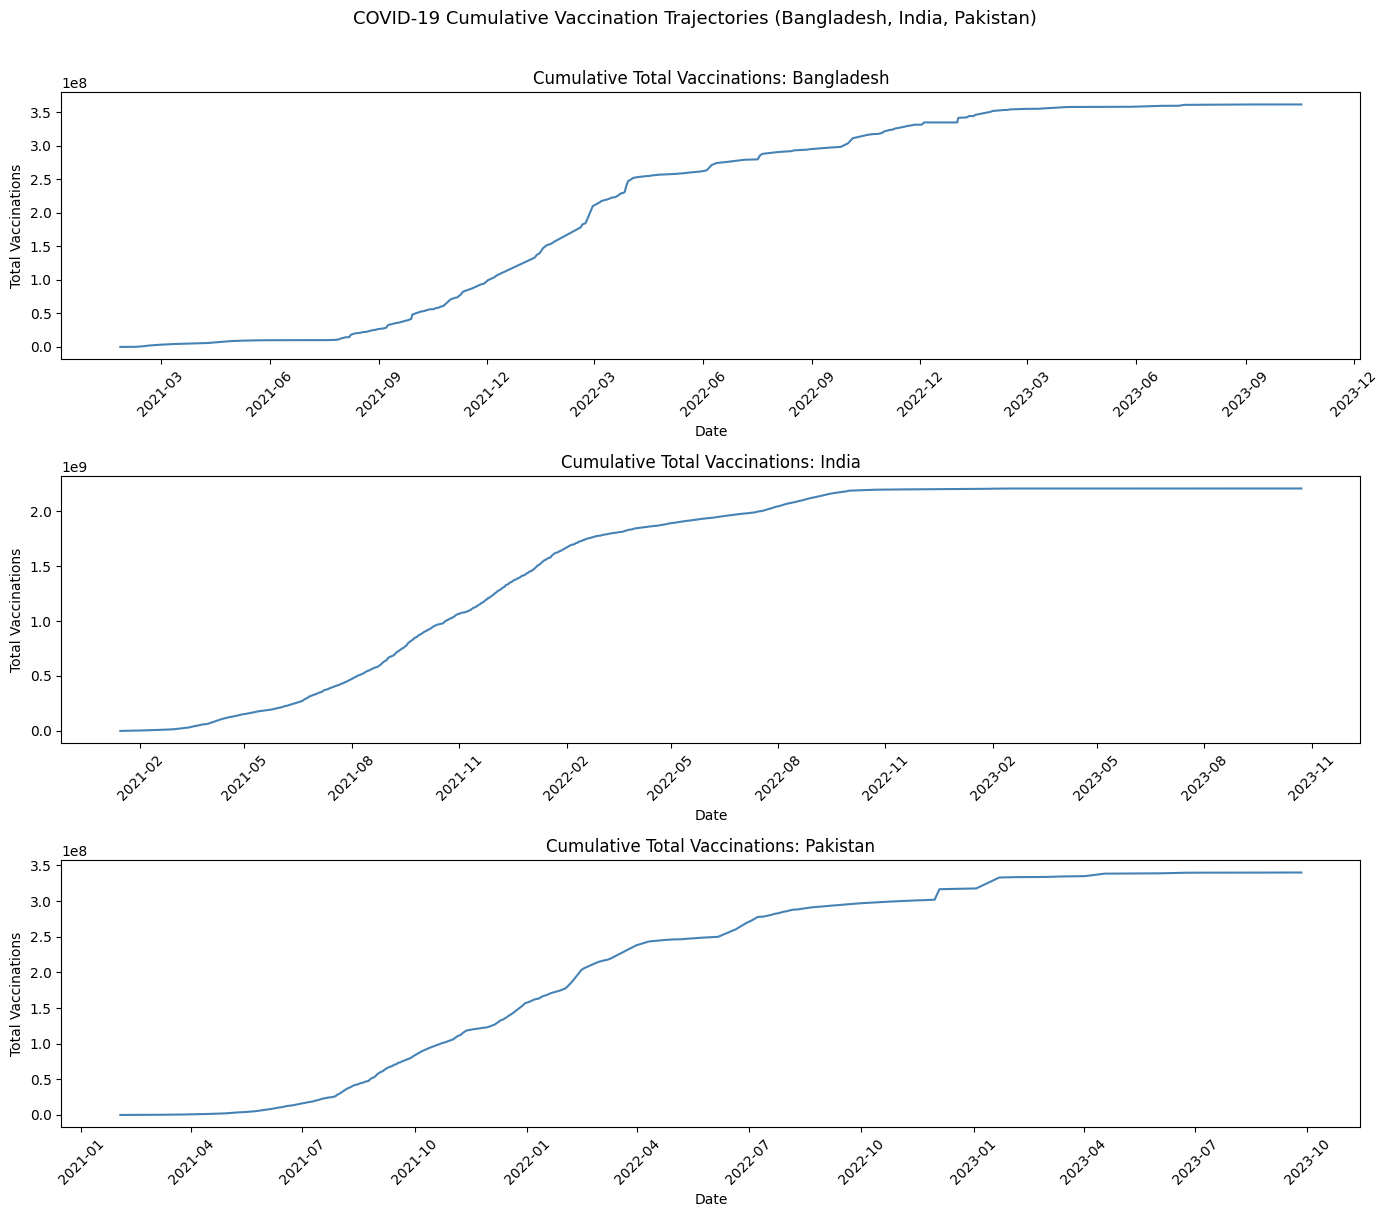

In [8]:
# Cell 7
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=False)

for ax, country in zip(axes, COUNTRIES):
    df = country_data[country]
    ax.plot(df.index, df['total_vaccinations'], linewidth=1.5, color='steelblue')
    ax.set_title(f'Cumulative Total Vaccinations: {country}')
    ax.set_xlabel('Date')
    ax.set_ylabel('Total Vaccinations')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.suptitle('COVID-19 Cumulative Vaccination Trajectories (Bangladesh, India, Pakistan)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'fig_01_raw_series.png'), dpi=150, bbox_inches='tight')
plt.show()


In [9]:
# Cell 8
def run_stationarity(series, label):
    adf_stat, adf_p, adf_lags, *_ = adfuller(series.dropna(), autolag='AIC')
    kpss_stat, kpss_p, kpss_lags, _ = kpss(series.dropna(), regression='c', nlags='auto')
    adf_conclusion  = 'Stationary'     if adf_p  < 0.05 else 'Non-Stationary'
    kpss_conclusion = 'Non-Stationary' if kpss_p < 0.05 else 'Stationary'
    return {
        'Series'          : label,
        'ADF Stat'        : round(adf_stat, 4),
        'ADF p'           : round(adf_p, 4),
        'ADF Conclusion'  : adf_conclusion,
        'KPSS Stat'       : round(kpss_stat, 4),
        'KPSS p'          : round(kpss_p, 4),
        'KPSS Conclusion' : kpss_conclusion
    }

stationarity_records = []

for country in COUNTRIES:
    series = country_data[country]['total_vaccinations']
    stationarity_records.append(run_stationarity(series,                 f'{country} | Level'))
    stationarity_records.append(run_stationarity(series.diff().dropna(), f'{country} | First Diff'))

stat_df = pd.DataFrame(stationarity_records).set_index('Series')
print("Stationarity Tests (ADF: H0=unit root present | KPSS: H0=series is stationary)\n")
print(stat_df.to_string())


Stationarity Tests (ADF: H0=unit root present | KPSS: H0=series is stationary)

                         ADF Stat   ADF p  ADF Conclusion  KPSS Stat  KPSS p KPSS Conclusion
Series                                                                                      
Bangladesh | Level        -1.4367  0.5646  Non-Stationary     4.8701    0.01  Non-Stationary
Bangladesh | First Diff   -4.6307  0.0001      Stationary     1.0873    0.01  Non-Stationary
India | Level             -3.0424  0.0311      Stationary     4.5261    0.01  Non-Stationary
India | First Diff        -1.3262  0.6171  Non-Stationary     2.5427    0.01  Non-Stationary
Pakistan | Level          -1.9105  0.3271  Non-Stationary     4.7001    0.01  Non-Stationary
Pakistan | First Diff     -5.3868  0.0000      Stationary     1.3074    0.01  Non-Stationary


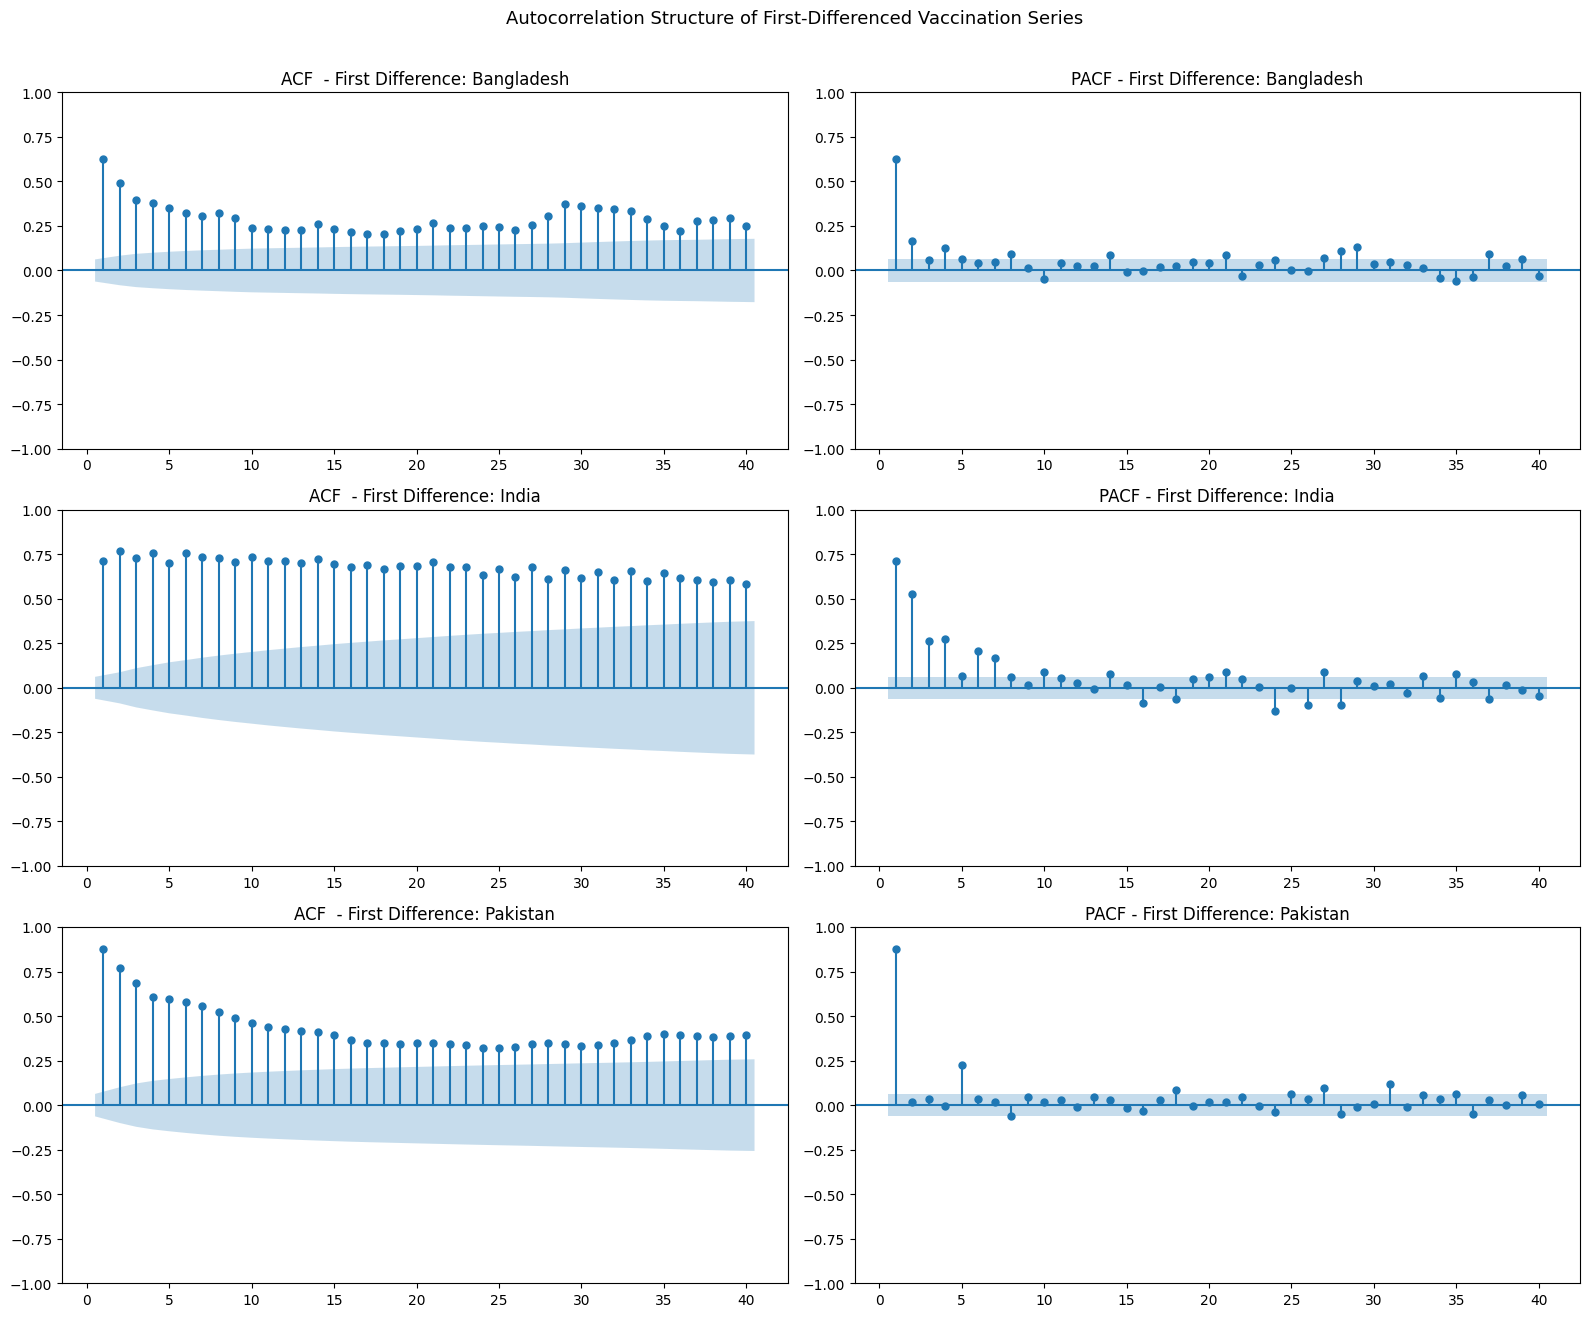

In [10]:
# Cell 9
fig, axes = plt.subplots(3, 2, figsize=(16, 13))

for i, country in enumerate(COUNTRIES):
    series_diff = country_data[country]['total_vaccinations'].diff().dropna()
    plot_acf(series_diff,  lags=40, ax=axes[i, 0],
             title=f'ACF  - First Difference: {country}', zero=False)
    plot_pacf(series_diff, lags=40, ax=axes[i, 1],
              title=f'PACF - First Difference: {country}', zero=False)

plt.suptitle('Autocorrelation Structure of First-Differenced Vaccination Series',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'fig_02_acf_pacf.png'), dpi=150, bbox_inches='tight')
plt.show()


In [11]:
# Cell 10
splits = {}

for country in COUNTRIES:
    df      = country_data[country]
    n       = len(df)
    split_n = int(n * TRAIN_RATIO)
    train   = df.iloc[:split_n].copy()
    test    = df.iloc[split_n:].copy()
    splits[country] = {'train': train, 'test': test}
    print(
        f"{country}: "
        f"train [{train.index[0].date()} -- {train.index[-1].date()}] n={len(train)} | "
        f"test  [{test.index[0].date()}  -- {test.index[-1].date()}]  n={len(test)}"
    )


Bangladesh: train [2021-01-26 -- 2023-04-01] n=796 | test  [2023-04-02  -- 2023-10-18]  n=200
India: train [2021-01-15 -- 2023-04-03] n=809 | test  [2023-04-04  -- 2023-10-23]  n=203
Pakistan: train [2021-02-02 -- 2023-03-16] n=773 | test  [2023-03-17  -- 2023-09-26]  n=194


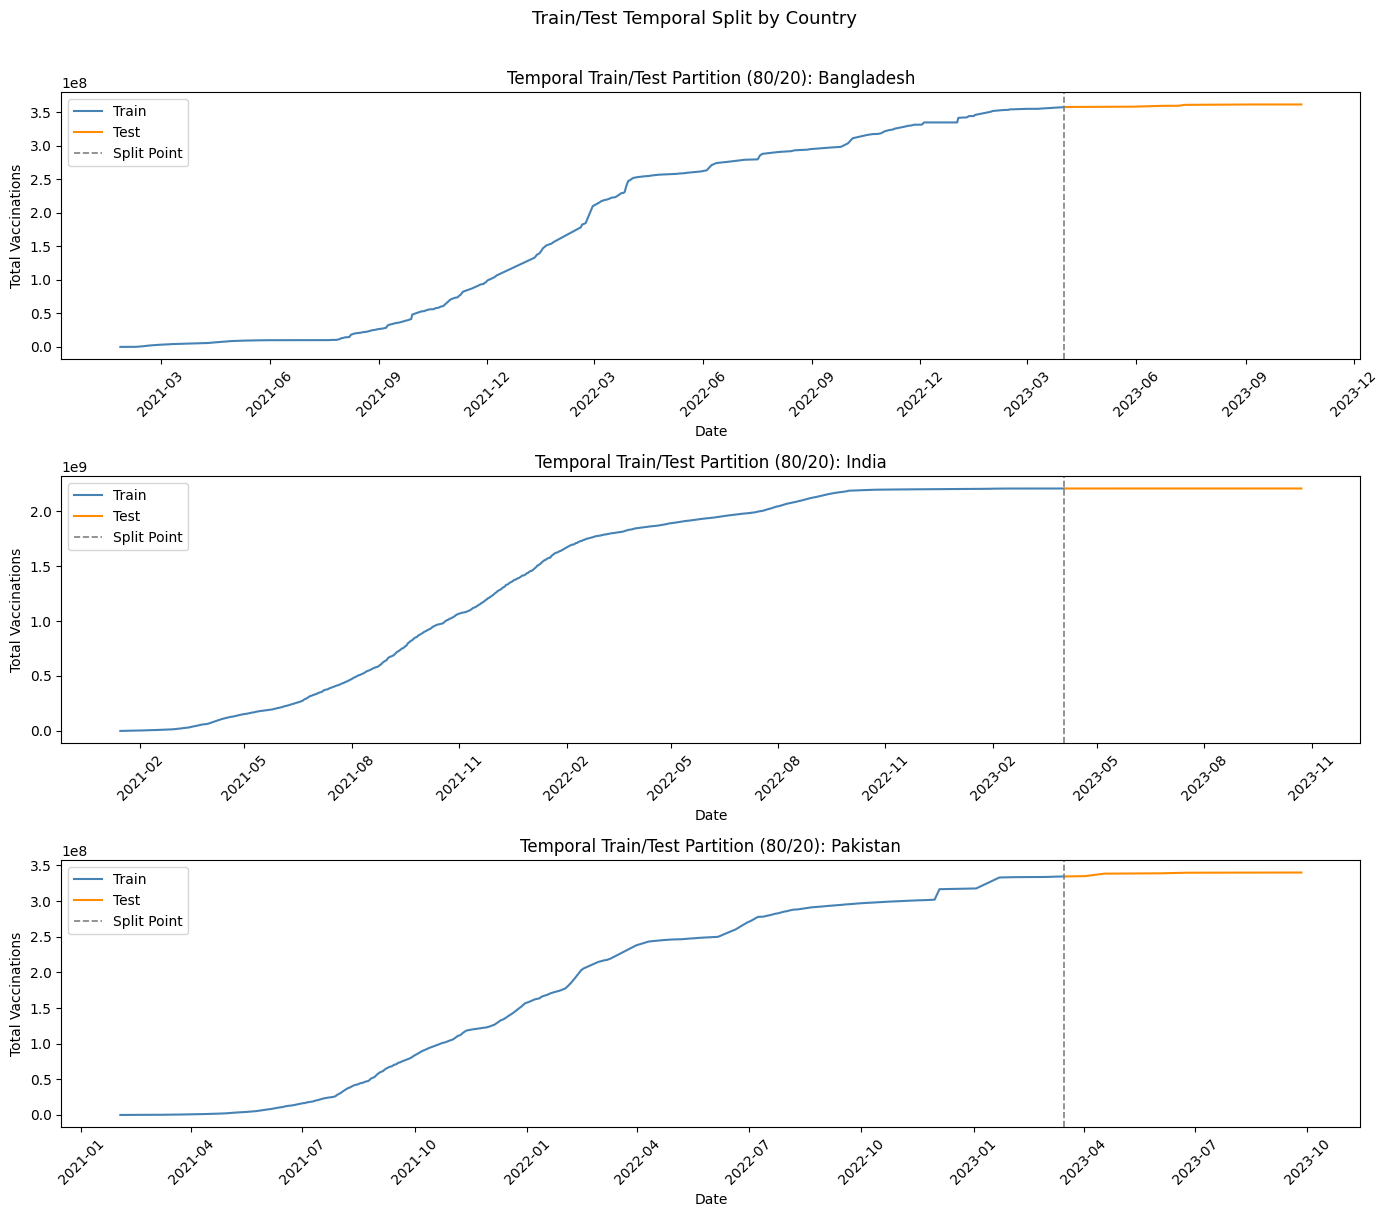

In [12]:
# Cell 11
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

for ax, country in zip(axes, COUNTRIES):
    train = splits[country]['train']
    test  = splits[country]['test']
    ax.plot(train.index, train['total_vaccinations'],
            label='Train', color='steelblue', linewidth=1.5)
    ax.plot(test.index,  test['total_vaccinations'],
            label='Test',  color='darkorange', linewidth=1.5)
    ax.axvline(x=train.index[-1], color='gray', linestyle='--',
               linewidth=1.2, label='Split Point')
    ax.set_title(f'Temporal Train/Test Partition (80/20): {country}')
    ax.set_xlabel('Date')
    ax.set_ylabel('Total Vaccinations')
    ax.legend()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.suptitle('Train/Test Temporal Split by Country', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'fig_03_train_test_split.png'), dpi=150, bbox_inches='tight')
plt.show()


In [13]:
# Cell 12
scalers       = {}
scaled_splits = {}

for country in COUNTRIES:
    scaler = StandardScaler()
    train  = splits[country]['train'][['total_vaccinations']]
    test   = splits[country]['test'][['total_vaccinations']]

    train_scaled = pd.DataFrame(
        scaler.fit_transform(train),
        index=train.index,
        columns=['total_vaccinations']
    )
    test_scaled = pd.DataFrame(
        scaler.transform(test),
        index=test.index,
        columns=['total_vaccinations']
    )

    scalers[country]       = scaler
    scaled_splits[country] = {'train': train_scaled, 'test': test_scaled}
    print(f"{country}: fit mean={scaler.mean_[0]:.4e}, std={scaler.scale_[0]:.4e}")


Bangladesh: fit mean=1.7562e+08, std=1.3458e+08
India: fit mean=1.3634e+09, std=8.2180e+08
Pakistan: fit mean=1.7515e+08, std=1.2196e+08


In [14]:
# Cell 12b – Naïve Persistence Baseline
# For each country: predict every test-set day as the last observed training value
# (already in original scale via splits, no inverse-transform needed)
naive_preds = {}
for country in COUNTRIES:
    last_train_val = splits[country]['train']['total_vaccinations'].iloc[-1]
    n_test = len(splits[country]['test'])
    naive_preds[country] = np.full(n_test, last_train_val)
    print(f"{country}: naïve baseline value = {last_train_val:.0f}  (repeated {n_test} times)")


Bangladesh: naïve baseline value = 357681223  (repeated 200 times)
India: naïve baseline value = 2206585373  (repeated 203 times)
Pakistan: naïve baseline value = 334565891  (repeated 194 times)


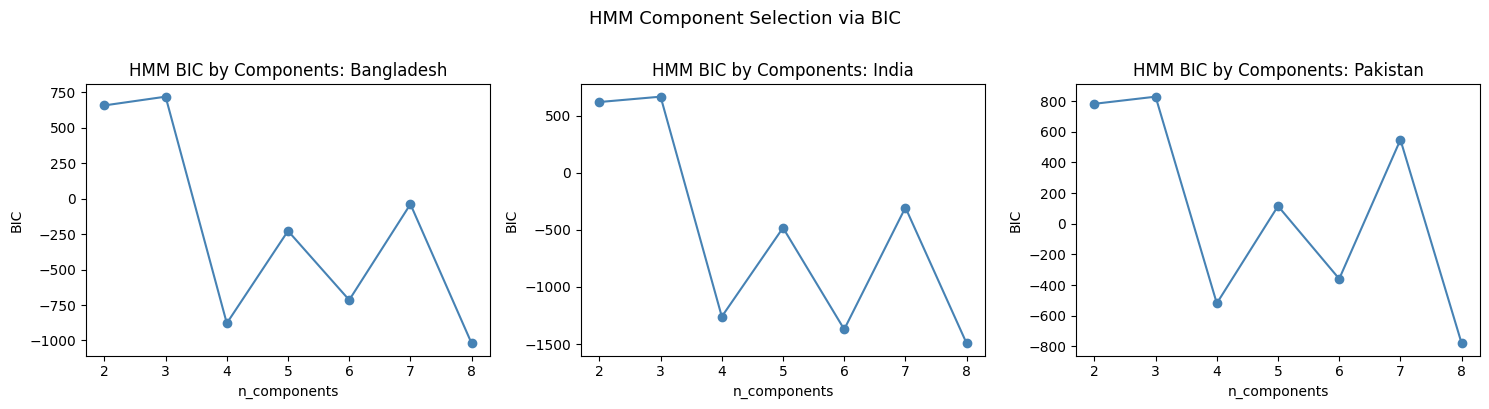

In [15]:
# Cell 13
hmm_bic_records = []
hmm_bic_df      = pd.DataFrame(columns=['Country', 'n_components', 'BIC'])

if HMM_AVAILABLE:
    for country in COUNTRIES:
        train_arr = scaled_splits[country]['train']['total_vaccinations'].values.reshape(-1, 1)
        n_obs     = len(train_arr)

        for n in range(2, 9):
            model = hmm.GaussianHMM(
                n_components=n,
                covariance_type=HMM_COV_TYPE,
                n_iter=HMM_N_ITER,
                random_state=RANDOM_STATE,
                min_covar=HMM_MIN_COVAR
            )
            model.fit(train_arr)
            log_lik  = model.score(train_arr)
            n_params = n * (n - 1) + (n - 1) + n + n
            bic      = -2 * log_lik + n_params * np.log(n_obs)
            hmm_bic_records.append({'Country': country, 'n_components': n, 'BIC': round(bic, 4)})

    hmm_bic_df = pd.DataFrame(hmm_bic_records)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, country in zip(axes, COUNTRIES):
        sub = hmm_bic_df[hmm_bic_df['Country'] == country]
        ax.plot(sub['n_components'], sub['BIC'], marker='o', color='steelblue')
        ax.set_title(f'HMM BIC by Components: {country}')
        ax.set_xlabel('n_components')
        ax.set_ylabel('BIC')
        ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

    plt.suptitle('HMM Component Selection via BIC', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, 'fig_04_hmm_bic.png'), dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("hmmlearn not available. Skipping HMM component selection.")


In [16]:
# Cell 14
hmm_optimal_n = {}

if HMM_AVAILABLE and not hmm_bic_df.empty:
    hmm_optimal_n = (
        hmm_bic_df.loc[hmm_bic_df.groupby('Country')['BIC'].idxmin()]
        .set_index('Country')['n_components']
        .to_dict()
    )
    print("BIC-optimal HMM components per country:")
    for country, n in hmm_optimal_n.items():
        best_bic = hmm_bic_df[
            (hmm_bic_df['Country'] == country) & (hmm_bic_df['n_components'] == n)
        ]['BIC'].values[0]
        print(f"  {country}: n_components = {n}  (BIC = {best_bic:.4f})")
else:
    print("hmmlearn not available. hmm_optimal_n left empty.")


BIC-optimal HMM components per country:
  Bangladesh: n_components = 8  (BIC = -1020.7248)
  India: n_components = 8  (BIC = -1493.9721)
  Pakistan: n_components = 8  (BIC = -779.7714)


In [17]:
# Cell 15
print("ARIMA Order Selection (pmdarima auto_arima | criterion: AIC | stepwise)\n")
arima_fits = {}

for country in COUNTRIES:
    train_series = scaled_splits[country]['train']['total_vaccinations']
    model = auto_arima(
        train_series,
        start_p=1, max_p=6,
        start_q=0, max_q=3,
        d=1,
        seasonal=False,
        information_criterion='aic',
        stepwise=True,
        error_action='ignore',
        suppress_warnings=True
    )
    arima_fits[country] = model
    print(f"{country}: ARIMA{model.order}  AIC={model.aic():.4f}")


ARIMA Order Selection (pmdarima auto_arima | criterion: AIC | stepwise)

Bangladesh: ARIMA(2, 1, 3)  AIC=-6369.4191
India: ARIMA(6, 1, 0)  AIC=-7670.7746
Pakistan: ARIMA(1, 1, 0)  AIC=-7328.7331


In [18]:
# Cell 16
print("SARIMA Order Selection (pmdarima auto_arima | criterion: AIC | m=7 | stepwise)\n")
sarima_fits = {}

for country in COUNTRIES:
    train_series = scaled_splits[country]['train']['total_vaccinations']
    model = auto_arima(
        train_series,
        start_p=1, max_p=4,
        start_q=0, max_q=2,
        d=1,
        seasonal=True, m=7,
        start_P=0, max_P=2,
        start_Q=0, max_Q=1,
        D=1,
        information_criterion='aic',
        stepwise=True,
        error_action='ignore',
        suppress_warnings=True
    )
    sarima_fits[country] = model
    print(f"{country}: SARIMA{model.order}x{model.seasonal_order}  AIC={model.aic():.4f}")


SARIMA Order Selection (pmdarima auto_arima | criterion: AIC | m=7 | stepwise)

Bangladesh: SARIMA(1, 1, 1)x(0, 1, 1, 7)  AIC=-6279.8356
India: SARIMA(2, 1, 0)x(0, 1, 1, 7)  AIC=-7484.6100
Pakistan: SARIMA(1, 1, 0)x(2, 1, 1, 7)  AIC=-7074.9364


In [19]:
# Cell 17
config_records = []
for country in COUNTRIES:
    record = {
        'Country'         : country,
        'ARIMA Order'     : str(arima_fits[country].order),
        'ARIMA AIC'       : round(arima_fits[country].aic(), 4),
        'SARIMA Order'    : str(sarima_fits[country].order),
        'SARIMA Seas.Ord' : str(sarima_fits[country].seasonal_order),
        'SARIMA AIC'      : round(sarima_fits[country].aic(), 4),
    }
    if HMM_AVAILABLE and country in hmm_optimal_n:
        record['HMM n_components'] = hmm_optimal_n[country]
    config_records.append(record)

config_df = pd.DataFrame(config_records).set_index('Country')
print("Selected Model Configurations\n")
print(config_df.to_string())
config_df.to_csv(os.path.join(OUT_DIR, 'model_configurations.csv'))


Selected Model Configurations

           ARIMA Order  ARIMA AIC SARIMA Order SARIMA Seas.Ord  SARIMA AIC  HMM n_components
Country                                                                                     
Bangladesh   (2, 1, 3) -6369.4191    (1, 1, 1)    (0, 1, 1, 7)  -6279.8356                 8
India        (6, 1, 0) -7670.7746    (2, 1, 0)    (0, 1, 1, 7)  -7484.6100                 8
Pakistan     (1, 1, 0) -7328.7331    (1, 1, 0)    (2, 1, 1, 7)  -7074.9364                 8


In [20]:
# Cell 18
def hmm_forecast_expected(model, train_array, steps):
    last_state = model.predict(train_array.reshape(-1, 1))[-1]
    state_dist  = np.zeros(model.n_components)
    state_dist[last_state] = 1.0
    forecasts = []
    for _ in range(steps):
        state_dist = state_dist @ model.transmat_
        expected   = np.dot(state_dist, model.means_.flatten())
        forecasts.append(expected)
    return np.array(forecasts)

hmm_fits = {}

if HMM_AVAILABLE and hmm_optimal_n:
    for country in COUNTRIES:
        train_arr = scaled_splits[country]['train']['total_vaccinations'].values
        n_comp    = hmm_optimal_n[country]
        model = hmm.GaussianHMM(
            n_components=n_comp,
            covariance_type=HMM_COV_TYPE,
            n_iter=HMM_N_ITER,
            random_state=RANDOM_STATE,
            min_covar=HMM_MIN_COVAR
        )
        model.fit(train_arr.reshape(-1, 1))
        hmm_fits[country] = model
        log_lik = model.score(train_arr.reshape(-1, 1))
        print(f"{country}: HMM fitted | n_components={n_comp} | train log-likelihood={log_lik:.4f}")
else:
    print("hmmlearn not available. Skipping HMM fitting.")


Bangladesh: HMM fitted | n_components=8 | train log-likelihood=774.2066
India: HMM fitted | n_components=8 | train log-likelihood=1011.4701
Pakistan: HMM fitted | n_components=8 | train log-likelihood=652.5717


In [21]:
def mape(actual, predicted):
    mask = actual != 0
    return np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100

metrics_records = []
test_forecasts  = {}

for country in COUNTRIES:
    train_series = scaled_splits[country]['train']['total_vaccinations']
    test_series  = scaled_splits[country]['test']['total_vaccinations']
    scaler       = scalers[country]
    n_test       = len(test_series)

    arima_pred_sc  = arima_fits[country].predict(n_periods=n_test)
    sarima_pred_sc = sarima_fits[country].predict(n_periods=n_test)

    actual      = scaler.inverse_transform(test_series.values.reshape(-1, 1)).flatten()
    arima_pred  = scaler.inverse_transform(np.asarray(arima_pred_sc).reshape(-1, 1)).flatten()
    sarima_pred = scaler.inverse_transform(np.asarray(sarima_pred_sc).reshape(-1, 1)).flatten()

    entry = {
        'actual' : actual,
        'arima'  : arima_pred,
        'sarima' : sarima_pred,
        'index'  : test_series.index
    }
    model_preds = [('ARIMA', arima_pred), ('SARIMA', sarima_pred)]

    if HMM_AVAILABLE and country in hmm_fits:
        hmm_pred_sc = hmm_forecast_expected(hmm_fits[country], train_series.values, n_test)
        hmm_pred    = scaler.inverse_transform(hmm_pred_sc.reshape(-1, 1)).flatten()
        entry['hmm'] = hmm_pred
        model_preds.append(('HMM', hmm_pred))

    naive_pred       = naive_preds[country]
    entry['naive']   = naive_pred
    model_preds.append(('Naive', naive_pred))

    test_forecasts[country] = entry

    for model_name, pred in model_preds:
        mae      = mean_absolute_error(actual, pred)
        mse      = mean_squared_error(actual, pred)
        rmse     = np.sqrt(mse)
        mape_val = mape(actual, pred)
        metrics_records.append({
            'Country' : country,
            'Model'   : model_name,
            'MAE'     : round(mae,      2),
            'MSE'     : round(mse,      2),
            'RMSE'    : round(rmse,     2),
            'MAPE (%)': round(mape_val, 4)
        })

metrics_df = pd.DataFrame(metrics_records)


In [22]:
# Cell 20
print("Out-of-Sample Evaluation Metrics (Test Set)\n")
print(metrics_df.to_string(index=False))
metrics_df.to_csv(os.path.join(OUT_DIR, 'evaluation_metrics.csv'), index=False)


Out-of-Sample Evaluation Metrics (Test Set)

   Country  Model          MAE          MSE         RMSE  MAPE (%)
Bangladesh  ARIMA  40263875.36 2.190262e+15  46800236.41   11.1554
Bangladesh SARIMA  18660098.50 4.617519e+14  21488412.24    5.1705
Bangladesh    HMM  20624995.58 4.279108e+14  20686003.85    5.7263
Bangladesh  Naive   2380606.61 8.187601e+12   2861398.37    0.6592
     India  ARIMA 153659387.04 3.641704e+16 190832490.50    6.9632
     India SARIMA   1138968.44 1.755255e+12   1324860.48    0.0516
     India    HMM   6517760.37 4.248337e+13   6517926.65    0.2954
     India  Naive    116306.83 1.569489e+10    125279.24    0.0053
  Pakistan  ARIMA  34810847.97 1.716531e+15  41431041.06   10.2481
  Pakistan SARIMA   1230380.94 2.192678e+12   1480769.50    0.3629
  Pakistan    HMM  32024186.65 1.028077e+15  32063643.88    9.4483
  Pakistan  Naive   4304917.14 2.106104e+13   4589230.82    1.2682


In [23]:
from scipy.stats import norm as _norm

def dm_test(errors_a, errors_b):
    """Two-sided Diebold-Mariano test (loss = squared error, simple variance estimator).

    H0: equal predictive accuracy.  Returns (DM statistic, two-sided p-value).
    """
    d     = errors_a ** 2 - errors_b ** 2
    T     = len(d)
    d_bar = d.mean()
    # Consistent under h=1; adequate for direct multi-step errors given the
    # asymptotic N(0,1) reference distribution requested.
    sigma2  = d.var(ddof=1)
    dm_stat = d_bar / np.sqrt(sigma2 / T)
    p_val   = 2 * (1 - _norm.cdf(abs(dm_stat)))
    return float(dm_stat), float(p_val)

dm_records = []

for country in COUNTRIES:
    tf     = test_forecasts[country]
    actual = tf['actual']

    errors = {
        'ARIMA':  actual - tf['arima'],
        'SARIMA': actual - tf['sarima'],
        'Naive':  actual - tf['naive'],
    }
    if 'hmm' in tf:
        errors['HMM'] = actual - tf['hmm']

    pairs = [('ARIMA', 'SARIMA'), ('ARIMA', 'Naive'), ('SARIMA', 'Naive')]
    if 'HMM' in errors:
        pairs += [('ARIMA', 'HMM'), ('SARIMA', 'HMM'), ('HMM', 'Naive')]

    for model_a, model_b in pairs:
        dm_stat, p_val = dm_test(errors[model_a], errors[model_b])
        dm_records.append({
            'Country'             : country,
            'Model A'             : model_a,
            'Model B'             : model_b,
            'DM Stat'             : round(dm_stat, 4),
            'p-value'             : round(p_val,   4),
            'Significant (p<0.05)': 'Yes' if p_val < 0.05 else 'No',
        })

dm_df = pd.DataFrame(dm_records)
print("Diebold-Mariano Test Results (H0: equal predictive accuracy | loss: squared error)\n")
print(dm_df.to_string(index=False))
dm_df.to_csv(os.path.join(OUT_DIR, 'dm_test_results.csv'), index=False)


Diebold-Mariano Test Results (H0: equal predictive accuracy | loss: squared error)

   Country Model A Model B   DM Stat  p-value Significant (p<0.05)
Bangladesh   ARIMA  SARIMA   15.3126   0.0000                  Yes
Bangladesh   ARIMA   Naive   15.3516   0.0000                  Yes
Bangladesh  SARIMA   Naive   15.4910   0.0000                  Yes
Bangladesh   ARIMA     HMM   12.7134   0.0000                  Yes
Bangladesh  SARIMA     HMM    1.3067   0.1913                   No
Bangladesh     HMM   Naive  102.2122   0.0000                  Yes
     India   ARIMA  SARIMA   13.0400   0.0000                  Yes
     India   ARIMA   Naive   13.0401   0.0000                  Yes
     India  SARIMA   Naive   15.2989   0.0000                  Yes
     India   ARIMA     HMM   13.0250   0.0000                  Yes
     India  SARIMA     HMM -478.3594   0.0000                  Yes
     India     HMM   Naive 1012.5928   0.0000                  Yes
  Pakistan   ARIMA  SARIMA   14.2231   0.0000

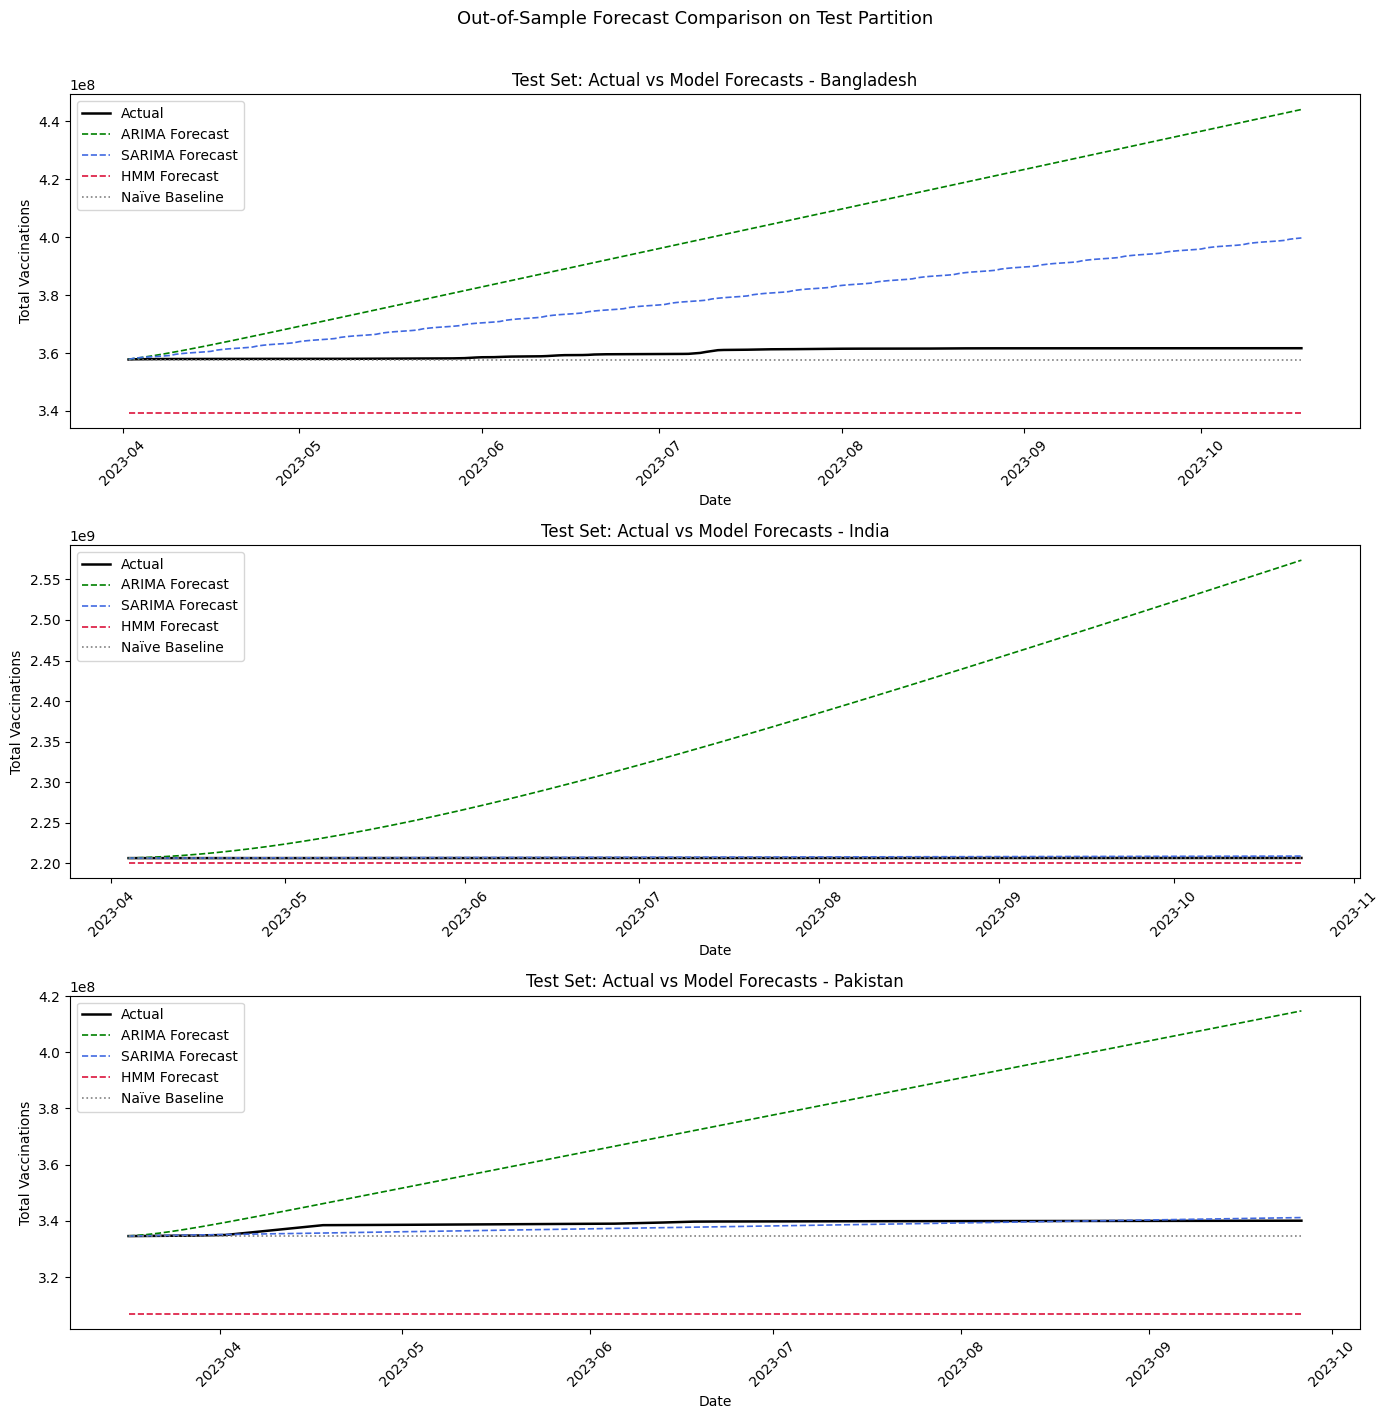

In [24]:
fig, axes = plt.subplots(3, 1, figsize=(14, 14))

for ax, country in zip(axes, COUNTRIES):
    tf  = test_forecasts[country]
    idx = tf['index']
    ax.plot(idx, tf['actual'], label='Actual',         color='black',     linewidth=1.8)
    ax.plot(idx, tf['arima'],  label='ARIMA Forecast',  color='green',     linestyle='--', linewidth=1.2)
    ax.plot(idx, tf['sarima'], label='SARIMA Forecast', color='royalblue', linestyle='--', linewidth=1.2)
    if 'hmm' in tf:
        ax.plot(idx, tf['hmm'], label='HMM Forecast',  color='crimson',   linestyle='--', linewidth=1.2)
    if 'naive' in tf:
        ax.plot(idx, tf['naive'], label='Naïve Baseline', color='gray',   linestyle=':',  linewidth=1.2)
    ax.set_title(f'Test Set: Actual vs Model Forecasts - {country}')
    ax.set_xlabel('Date')
    ax.set_ylabel('Total Vaccinations')
    ax.legend()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.suptitle('Out-of-Sample Forecast Comparison on Test Partition', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'fig_05_test_forecast_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()


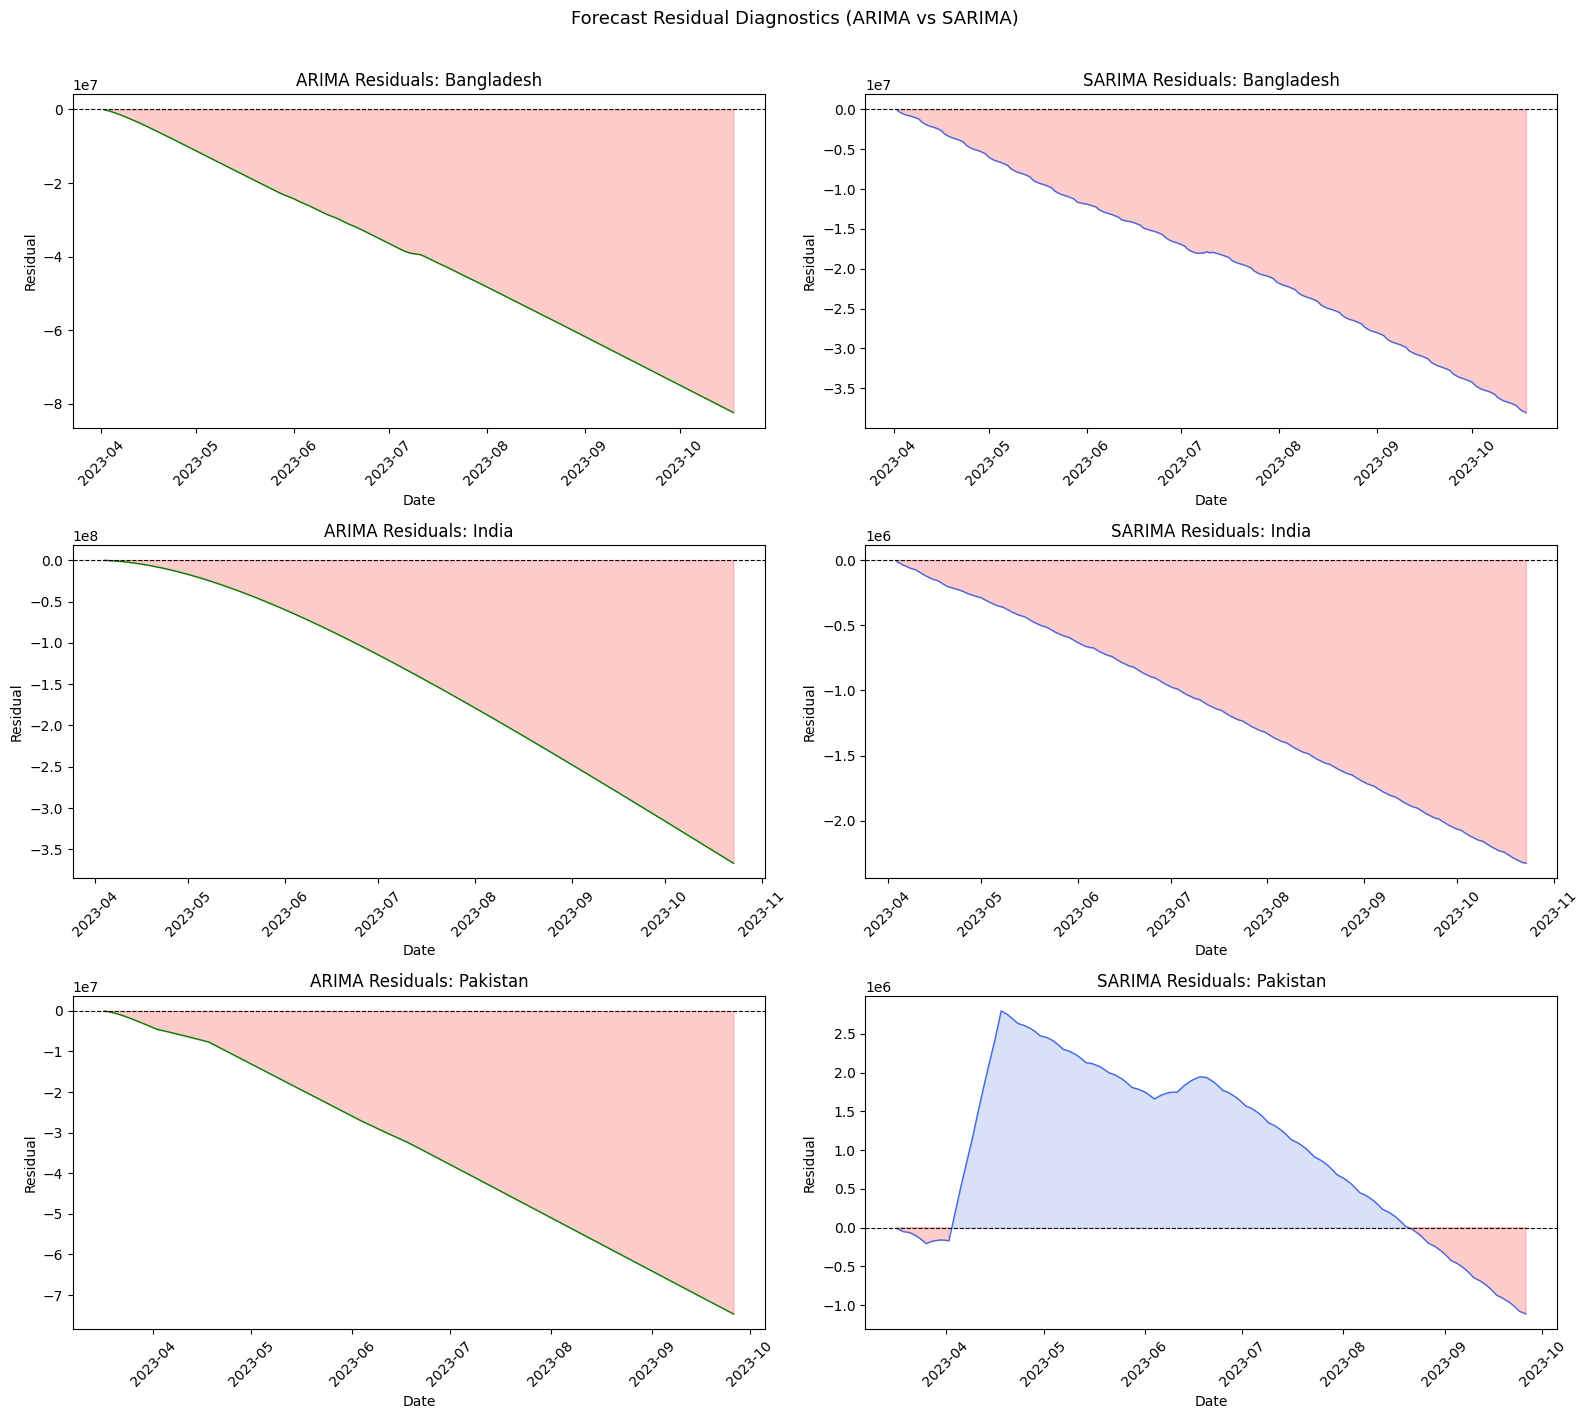

In [25]:
# Cell 22
fig, axes = plt.subplots(3, 2, figsize=(16, 14))

for i, country in enumerate(COUNTRIES):
    tf               = test_forecasts[country]
    idx              = tf['index']
    arima_residuals  = tf['actual'] - tf['arima']
    sarima_residuals = tf['actual'] - tf['sarima']

    axes[i, 0].plot(idx, arima_residuals, color='green', linewidth=1)
    axes[i, 0].axhline(0, color='black', linestyle='--', linewidth=0.8)
    axes[i, 0].fill_between(idx, arima_residuals, 0,
                             where=(arima_residuals > 0), alpha=0.2, color='green')
    axes[i, 0].fill_between(idx, arima_residuals, 0,
                             where=(arima_residuals < 0), alpha=0.2, color='red')
    axes[i, 0].set_title(f'ARIMA Residuals: {country}')
    axes[i, 0].set_xlabel('Date')
    axes[i, 0].set_ylabel('Residual')
    axes[i, 0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    axes[i, 0].xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    plt.setp(axes[i, 0].xaxis.get_majorticklabels(), rotation=45)

    axes[i, 1].plot(idx, sarima_residuals, color='royalblue', linewidth=1)
    axes[i, 1].axhline(0, color='black', linestyle='--', linewidth=0.8)
    axes[i, 1].fill_between(idx, sarima_residuals, 0,
                             where=(sarima_residuals > 0), alpha=0.2, color='royalblue')
    axes[i, 1].fill_between(idx, sarima_residuals, 0,
                             where=(sarima_residuals < 0), alpha=0.2, color='red')
    axes[i, 1].set_title(f'SARIMA Residuals: {country}')
    axes[i, 1].set_xlabel('Date')
    axes[i, 1].set_ylabel('Residual')
    axes[i, 1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    axes[i, 1].xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    plt.setp(axes[i, 1].xaxis.get_majorticklabels(), rotation=45)

plt.suptitle('Forecast Residual Diagnostics (ARIMA vs SARIMA)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'fig_06_residuals.png'), dpi=150, bbox_inches='tight')
plt.show()


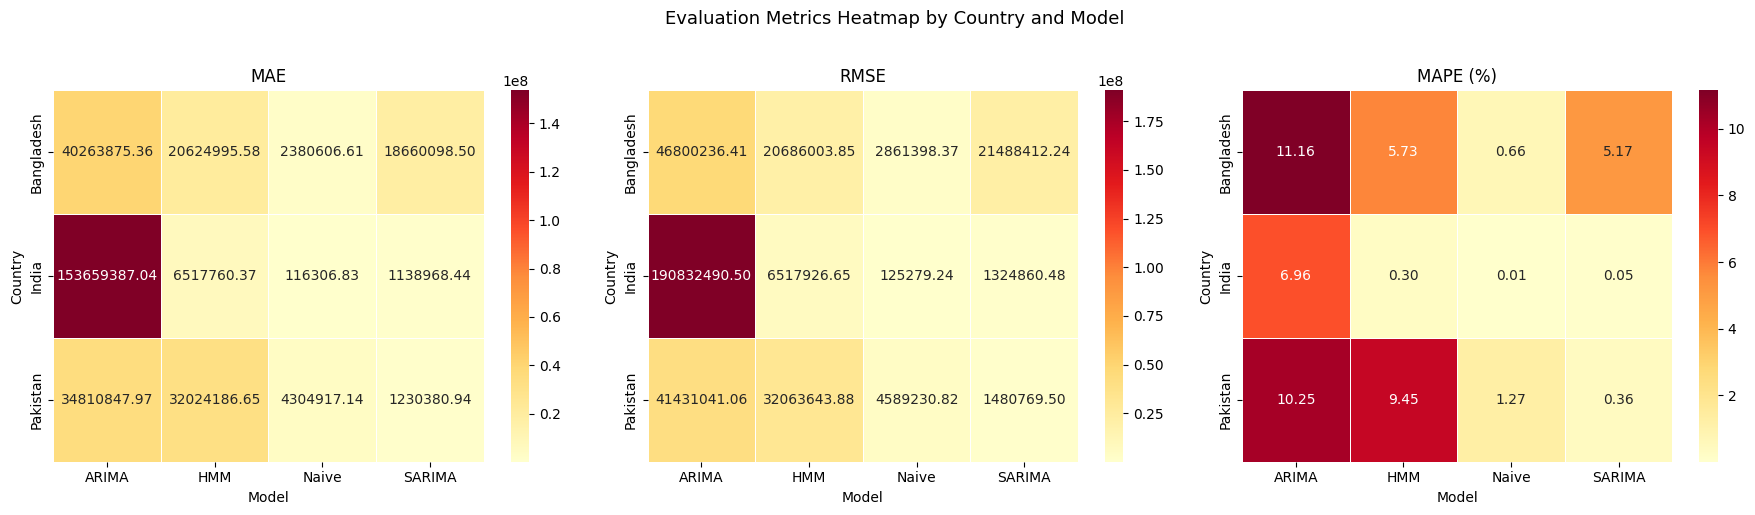

In [26]:
# Cell 23
metrics_plot = ['MAE', 'RMSE', 'MAPE (%)']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, metric in zip(axes, metrics_plot):
    pivot = metrics_df.pivot(index='Country', columns='Model', values=metric)
    sns.heatmap(
        pivot, annot=True, fmt='.2f', cmap='YlOrRd',
        ax=ax, linewidths=0.5, cbar=True
    )
    ax.set_title(metric)
    ax.set_xlabel('Model')
    ax.set_ylabel('Country')

plt.suptitle('Evaluation Metrics Heatmap by Country and Model', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'fig_07_metrics_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()


In [27]:
future_forecasts = {}

for country in COUNTRIES:
    train_sc = scaled_splits[country]['train']['total_vaccinations']
    test_sc  = scaled_splits[country]['test']['total_vaccinations']
    full_sc  = pd.concat([train_sc, test_sc])
    full_arr = full_sc.values
    scaler   = scalers[country]

    last_date    = country_data[country].index.max()
    future_dates = pd.date_range(
        start=last_date + pd.Timedelta(days=1),
        periods=FORECAST_HORIZON,
        freq='D'
    )

    arima_full  = ARIMA(full_sc, order=arima_fits[country].order).fit()
    sarima_full = SARIMAX(
        full_sc,
        order=sarima_fits[country].order,
        seasonal_order=sarima_fits[country].seasonal_order
    ).fit(disp=False)

    arima_fc  = arima_full.get_forecast(steps=FORECAST_HORIZON).summary_frame(alpha=0.05)
    sarima_fc = sarima_full.get_forecast(steps=FORECAST_HORIZON).summary_frame(alpha=0.05)

    def _inv(arr):
        return scaler.inverse_transform(np.asarray(arr).reshape(-1, 1)).flatten()

    entry = {
        'dates'        : future_dates,
        'arima'        : _inv(arima_fc['mean']),
        'arima_lower'  : _inv(arima_fc['mean_ci_lower']),
        'arima_upper'  : _inv(arima_fc['mean_ci_upper']),
        'sarima'       : _inv(sarima_fc['mean']),
        'sarima_lower' : _inv(sarima_fc['mean_ci_lower']),
        'sarima_upper' : _inv(sarima_fc['mean_ci_upper']),
    }

    if HMM_AVAILABLE and country in hmm_fits:
        hmm_full = hmm.GaussianHMM(
            n_components=hmm_optimal_n[country],
            covariance_type=HMM_COV_TYPE,
            n_iter=HMM_N_ITER,
            random_state=RANDOM_STATE,
            min_covar=HMM_MIN_COVAR
        )
        hmm_full.fit(full_arr.reshape(-1, 1))
        hmm_fut_sc   = hmm_forecast_expected(hmm_full, full_arr, FORECAST_HORIZON)
        entry['hmm'] = scaler.inverse_transform(hmm_fut_sc.reshape(-1, 1)).flatten()

    future_forecasts[country] = entry
    print(
        f"{country}: forecast window "
        f"{future_dates[0].date()} to {future_dates[-1].date()}"
    )


Bangladesh: forecast window 2023-10-19 to 2024-04-15
India: forecast window 2023-10-24 to 2024-04-20
Pakistan: forecast window 2023-09-27 to 2024-03-24


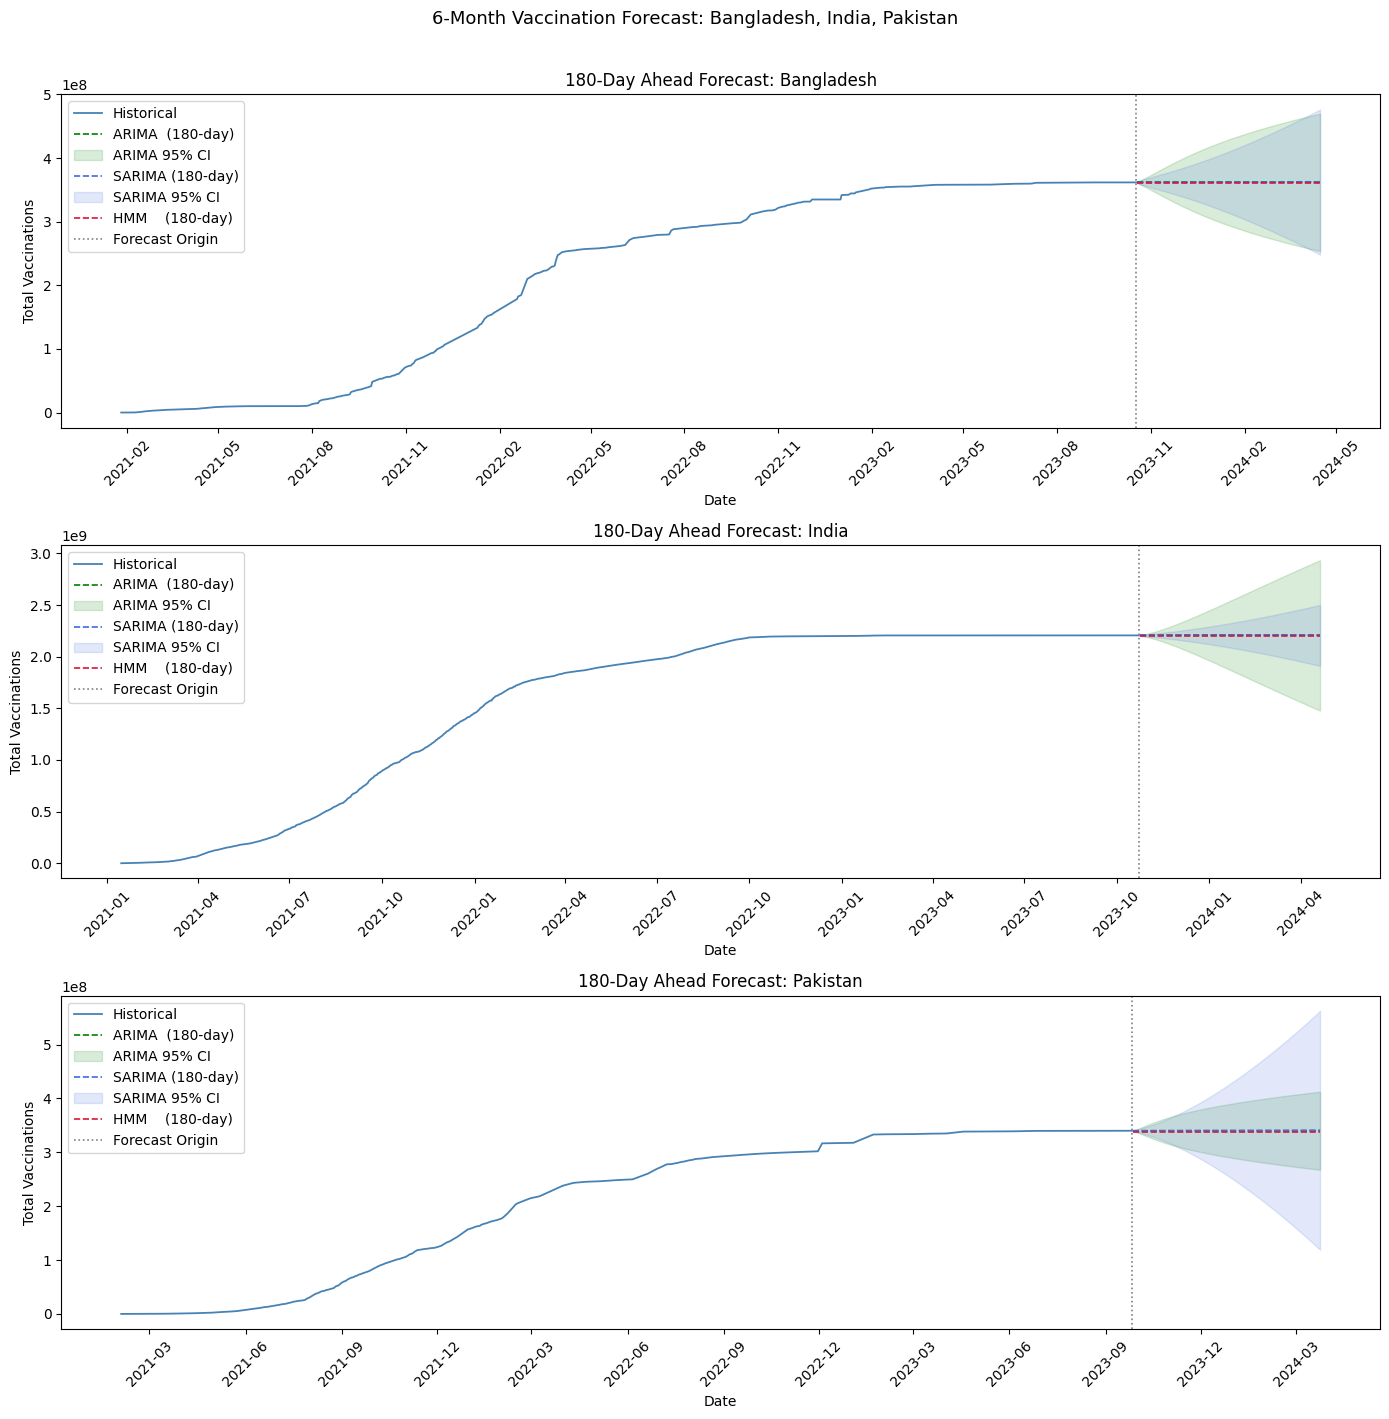

In [28]:
fig, axes = plt.subplots(3, 1, figsize=(14, 14))

for ax, country in zip(axes, COUNTRIES):
    hist = country_data[country]
    ff   = future_forecasts[country]

    ax.plot(hist.index, hist['total_vaccinations'],
            label='Historical', color='steelblue', linewidth=1.3)

    ax.plot(ff['dates'], ff['arima'],
            label='ARIMA  (180-day)', color='green', linestyle='--', linewidth=1.2)
    if 'arima_lower' in ff:
        ax.fill_between(ff['dates'], ff['arima_lower'], ff['arima_upper'],
                        color='green', alpha=0.15, label='ARIMA 95% CI')

    ax.plot(ff['dates'], ff['sarima'],
            label='SARIMA (180-day)', color='royalblue', linestyle='--', linewidth=1.2)
    if 'sarima_lower' in ff:
        ax.fill_between(ff['dates'], ff['sarima_lower'], ff['sarima_upper'],
                        color='royalblue', alpha=0.15, label='SARIMA 95% CI')

    if 'hmm' in ff:
        ax.plot(ff['dates'], ff['hmm'],
                label='HMM    (180-day)', color='crimson', linestyle='--', linewidth=1.2)

    ax.axvline(x=hist.index.max(), color='gray', linestyle=':', linewidth=1.2,
               label='Forecast Origin')
    ax.set_title(f'180-Day Ahead Forecast: {country}')
    ax.set_xlabel('Date')
    ax.set_ylabel('Total Vaccinations')
    ax.legend()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.suptitle('6-Month Vaccination Forecast: Bangladesh, India, Pakistan', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'fig_08_future_forecast.png'), dpi=150, bbox_inches='tight')
plt.show()
